## 1. Project Title
### Predictive Forecasting of Care Load & Placement Demand

#### The project uses historical daily data to predict:

##### * Future children in HHS care
##### * Future transfers into HHS care
##### * Future discharge/placement demand
##### * Possible capacity pressure

##### The main purpose is to help planners prepare resources in advance instead of reacting after demand increases.

## 2. Background and Context

#### The document explains that the UAC program operates in an uncertain environment.

#### Events such as:

##### * Changes in border activity
##### * Policy changes
##### * Humanitarian situations
##### * Changes in transfers
##### * Changes in discharge rates

##### can cause the number of children requiring care to change quickly.

##### Traditional analytics tells us:

##### What happened?

##### Predictive analytics tries to answer:

##### What is likely to happen next?

##### That is why forecasting is important.

## 3. Problem Statement

#### The current system has historical daily data, but it does not sufficiently provide:

##### * Short-term care-load forecasts
##### * Future discharge/placement demand
##### * Early warnings about capacity pressure

##### Without forecasting, organizations may react too late.

#####  Possible operational consequences include:

##### * Overcrowding
##### * Staff workload
##### * Resource shortages
##### * Longer stays

## 4. Project Workflow

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error,mean_squared_error,mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.arima.model import ARIMA
import joblib
from sklearn.model_selection import train_test_split

In [2]:
healthcare = pd.read_csv("HHS_Unaccompanied_Alien_Children_Program - HHS_Unaccompanied_Alien_Children_Program.csv")

In [3]:
healthcare.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6,18,11,"2,484",14
1,"December 18, 2025",11,50,6,"2,472",16
2,"December 17, 2025",7,31,11,"2,481",10
3,"December 16, 2025",8,54,15,"2,468",9
4,"December 15, 2025",11,42,9,"2,470",7


In [4]:
healthcare.shape

(720, 6)

In [5]:
healthcare.info()

<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype
---  ------                                           --------------  -----
 0   Date                                             720 non-null    str  
 1   Children apprehended and placed in CBP custody*  720 non-null    int64
 2   Children in CBP custody                          720 non-null    int64
 3   Children transferred out of CBP custody          720 non-null    int64
 4   Children in HHS Care                             720 non-null    str  
 5   Children discharged from HHS Care                720 non-null    int64
dtypes: int64(4), str(2)
memory usage: 48.1 KB


In [6]:
healthcare.columns =(healthcare.columns.str.strip().str.lower().str.replace(" ","_").str.replace("-","_"))
print(healthcare.columns)

Index(['date', 'children_apprehended_and_placed_in_cbp_custody*',
       'children_in_cbp_custody', 'children_transferred_out_of_cbp_custody',
       'children_in_hhs_care', 'children_discharged_from_hhs_care'],
      dtype='str')


In [7]:
healthcare["date"] = pd.to_datetime(healthcare["date"])
healthcare =healthcare.sort_values("date")
healthcare = healthcare.set_index("date")
healthcare.head()

,children_apprehended_and_placed_in_cbp_custody*,children_in_cbp_custody,children_transferred_out_of_cbp_custody,children_in_hhs_care,children_discharged_from_hhs_care
date,,,,,
2023-01-12,33,53,34,"6,566",436
2023-01-22,32,49,39,"7,122",227
2023-01-23,32,50,39,"7,280",181
2023-01-24,47,42,47,"7,433",175
2023-01-25,20,22,41,"7,538",180


In [8]:
healthcare.isnull().sum()

children_apprehended_and_placed_in_cbp_custody*    0
children_in_cbp_custody                            0
children_transferred_out_of_cbp_custody            0
children_in_hhs_care                               0
children_discharged_from_hhs_care                  0
dtype: int64

In [9]:
missing = healthcare.isnull().mean()*100
print(missing)

children_apprehended_and_placed_in_cbp_custody*    0.0
children_in_cbp_custody                            0.0
children_transferred_out_of_cbp_custody            0.0
children_in_hhs_care                               0.0
children_discharged_from_hhs_care                  0.0
dtype: float64


In [10]:
healthcare.index.duplicated().sum()

np.int64(0)

In [11]:
healthcare = healthcare[~healthcare.index.duplicated(keep="first")]

In [12]:
full_date = pd.date_range(start=healthcare.index.min(), end= healthcare.index.max(), freq="D")
healthcare = healthcare.reindex(full_date)
healthcare.index.name = "date"
healthcare.isnull().sum()


children_apprehended_and_placed_in_cbp_custody*    355
children_in_cbp_custody                            355
children_transferred_out_of_cbp_custody            355
children_in_hhs_care                               355
children_discharged_from_hhs_care                  355
dtype: int64

In [13]:
numeric_colums = healthcare.select_dtypes(include=np.number).columns
healthcare[numeric_colums] = healthcare[numeric_colums].interpolate(method="time")

In [14]:
healthcare = healthcare.ffill().bfill()

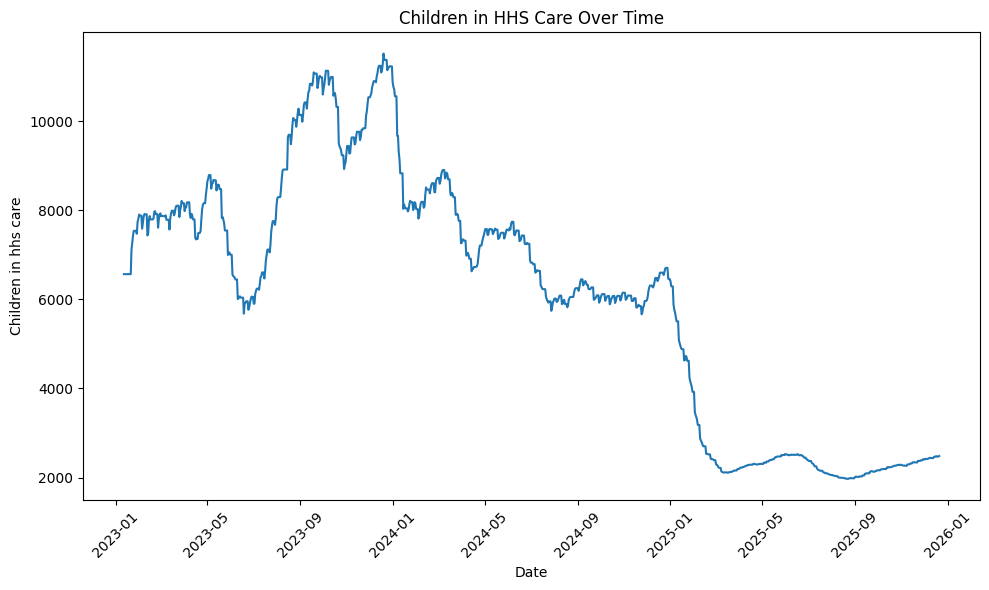

In [15]:
plt.figure(figsize=(10,6))
plt.plot(healthcare.index,pd.to_numeric(healthcare["children_in_hhs_care"].astype(str).str.replace(",", ""),errors="coerce"))
plt.title("Children in HHS Care Over Time")
plt.xlabel("Date")
plt.ylabel("Children in hhs care")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

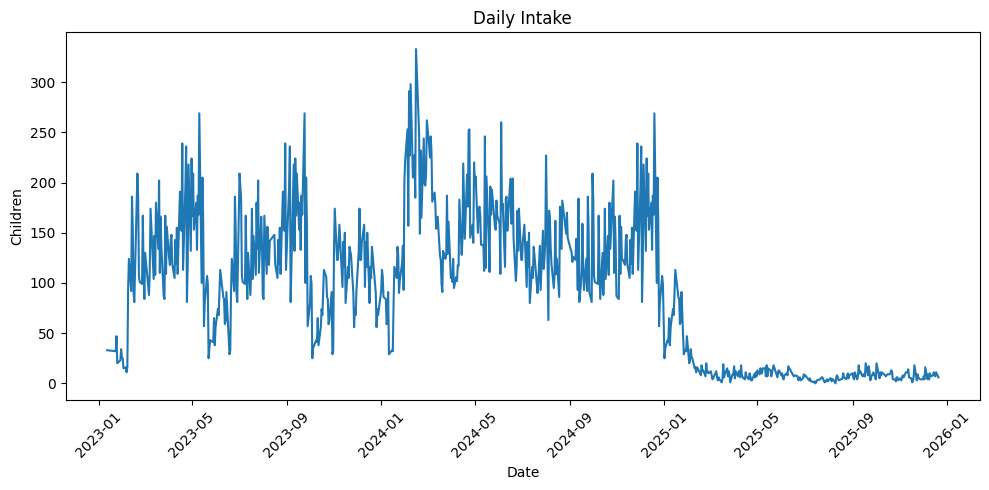

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(healthcare.index,pd.to_numeric(healthcare["children_apprehended_and_placed_in_cbp_custody*"],errors="coerce"))
plt.title("Daily Intake")
plt.xlabel("Date")
plt.ylabel("Children")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

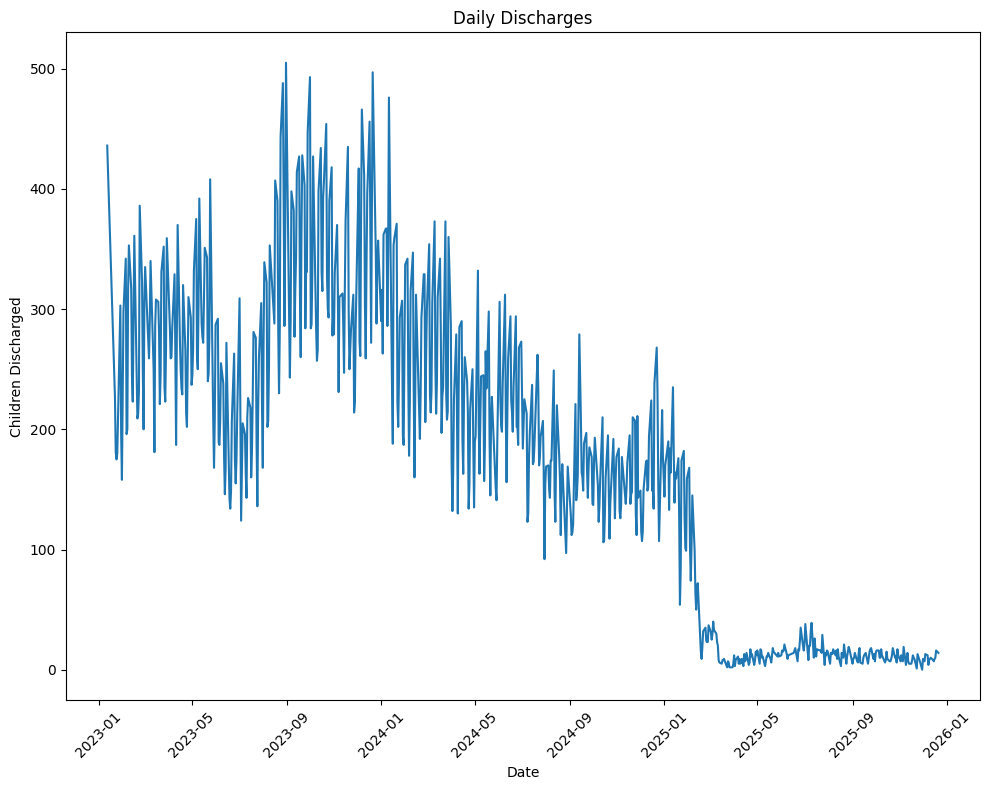

In [17]:
plt.figure(figsize=(10,8))
plt.plot(healthcare.index, pd.to_numeric (healthcare["children_discharged_from_hhs_care"],errors="coerce"))
plt.title("Daily Discharges")
plt.xlabel("Date")
plt.ylabel("Children Discharged")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
healthcare["net_pressure"] = (healthcare["children_transferred_out_of_cbp_custody"] - healthcare["children_discharged_from_hhs_care"])

In [19]:
healthcare["core_load_change"] = ( healthcare ["children_in_hhs_care"].diff)

In [20]:
healthcare["lag_1"] = (healthcare["children_in_hhs_care"].shift(1))
healthcare["lag_7"] = healthcare["children_in_hhs_care"].shift(7)
healthcare["lag_14"] = (healthcare["children_in_hhs_care"].shift(14))

In [21]:
healthcare["children_in_hhs_care"] = pd.to_numeric(
    healthcare["children_in_hhs_care"].astype(str).str.replace(",", "", regex=False),
    errors="coerce"
)

healthcare["core_load_change"] = healthcare["children_in_hhs_care"].diff()
healthcare["lag_1"] = healthcare["children_in_hhs_care"].shift(1)
healthcare["lag_7"] = healthcare["children_in_hhs_care"].shift(7)
healthcare["lag_14"] = healthcare["children_in_hhs_care"].shift(14)

healthcare["rolling_mean_7"] = healthcare["children_in_hhs_care"].rolling(7).mean()
healthcare["rolling_mean_14"] = (healthcare["children_in_hhs_care"].rolling(14).mean())
healthcare["rolling_mean_7"] = (healthcare["children_in_hhs_care"].rolling(7).std())

In [22]:
healthcare["day_of_week"] = healthcare.index.dayofweek
healthcare["month"] = healthcare.index.month
healthcare["day"] = healthcare.index.day
healthcare["is_weekend"] = (healthcare["day_of_week"]>=5).astype(int)

In [23]:
healthcare = healthcare.dropna()

In [24]:
healthcare.head()

,children_apprehended_and_placed_in_cbp_custody*,children_in_cbp_custody,children_transferred_out_of_cbp_custody,children_in_hhs_care,children_discharged_from_hhs_care,net_pressure,core_load_change,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_14,day_of_week,month,day,is_weekend
date,,,,,,,,,,,,,,,,
2023-01-26,20.75,27.75,33.5,7538,210.75,-177.25,0.0,7538.0,6566.0,6566.0,424.453767,6857.500000,3,1,26,0
2023-01-27,21.50,33.50,26.0,7538,241.50,-215.50,0.0,7538.0,6566.0,6566.0,355.300074,6926.928571,4,1,27,0
2023-01-28,22.25,39.25,18.5,7538,272.25,-253.75,0.0,7538.0,6566.0,6566.0,165.304481,6996.357143,5,1,28,1
2023-01-29,23.00,45.00,11.0,7472,303.00,-292.00,-66.0,7538.0,7122.0,6566.0,96.309768,7061.071429,6,1,29,1
2023-01-30,34.00,54.00,29.0,7743,196.00,-167.00,271.0,7472.0,7280.0,6566.0,97.673655,7145.142857,0,1,30,0


In [25]:
healthcare.shape

(1061, 16)

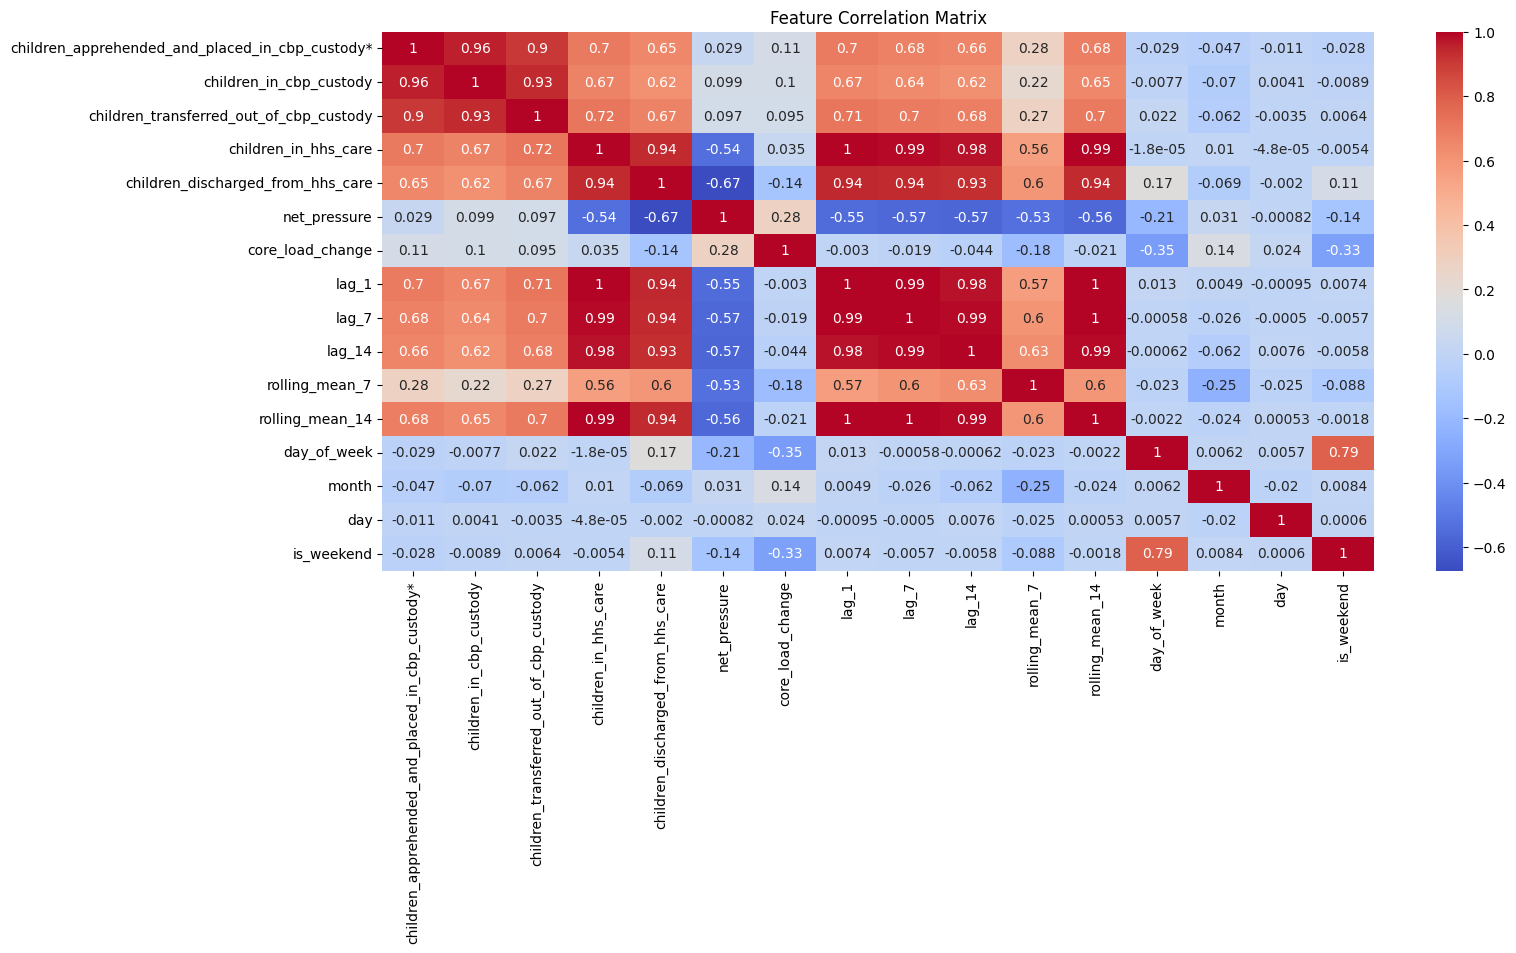

In [26]:
plt.figure(figsize=(16,7))
correlation = healthcare.corr(numeric_only=True)
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

In [27]:
target = "children_in_hhs_care"
X = healthcare.drop(columns=[target])
y = healthcare[target]

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.80, test_size=0.20)

In [29]:
split_index = int(len(healthcare) * 0.80)
X_train =X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]
print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (848, 15)
Testing: (213, 15)


In [30]:
naive_predictions = y_test.shift(1)

In [31]:
naive_predictions.iloc[0] = y_train.iloc[-1]

In [32]:
mae = mean_absolute_error(y_test, naive_predictions)

In [33]:
print("\n Naive MAE :", mae)


 Naive MAE : 6.652582159624413


In [34]:
rmse = np.sqrt(mean_squared_error(y_test, naive_predictions))

In [35]:
print("\n Naive RMSE :", rmse)


 Naive RMSE : 11.34168430247031


In [36]:
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true !=0
    return np.mean(np.abs((y_true[mask]-y_pred[mask])/ y_true[mask]))*100

In [37]:
print("\n MAPE:", mape(y_test, naive_predictions))


 MAPE: 0.29509254168878213


In [38]:
features = ["lag_1", "lag_7", "lag_14", "rolling_mean_7", "rolling_mean_14", "rolling_std_7", "net_pressure", "day_of_week","month","is_weekend"]

In [39]:
healthcare["rolling_mean_7"] = (
    healthcare[target].rolling(window=7).mean()
)
healthcare["rolling_std_7"] = (
    healthcare[target].rolling(window=7).std()
)

healthcare = healthcare.dropna(subset=features + [target])

X = healthcare[features]
y = healthcare[target]

split_index = int(len(healthcare) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]
y = healthcare[target]

split_index = int(len(healthcare) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [40]:
model = RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42,n_jobs=-1)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

In [41]:
pred = model.predict(X_test)

In [42]:
mae_1 = mean_absolute_error(y_test, pred)

In [43]:
print("\nRandom Forest MAE:", mae_1)


Random Forest MAE: 44.148867768750456


In [44]:
rmse_1 = np.sqrt(mean_squared_error(y_test, pred))

In [45]:
print("\nRandom Forest RMSE:", rmse_1)



Random Forest RMSE: 66.753582843013


In [46]:
mape_1 = mape(y_test, pred)

In [47]:
print("\nRandom Forest MAPE:", mape_1)


Random Forest MAPE: 2.0935071420411866


In [48]:
gb_model = GradientBoostingRegressor(n_estimators=300,learning_rate=0.05,max_depth=3,random_state=42)

In [49]:
gb_model.fit(X_train,y_train)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, in

In [50]:
gb_predictions = gb_model.predict(X_test)

In [51]:
mae_2 = mean_absolute_error(y_test,gb_predictions)

rmse_2 = np.sqrt(mean_squared_error(y_test,gb_predictions))

mape_2 = mape(y_test,gb_predictions)

print("Gradient Boosting MAE:", mae_2)
print("Gradient Boosting RMSE:", rmse_2)
print("Gradient Boosting MAPE:", mape_2)

Gradient Boosting MAE: 52.462877203167885
Gradient Boosting RMSE: 75.13732486999602
Gradient Boosting MAPE: 2.4888700915989292


In [52]:
result = pd.DataFrame({
    "model": ["naive","Random Forest","Gradient Boosting"],
    "MAE": [mae,mae_1,mae_2],
    "RMSE": [rmse,rmse_1,rmse_2],
    "MAPE" : [mape,mape_1,mape_2]
})
result

,model,MAE,RMSE,MAPE
0,naive,6.652582,11.341684,<function mape at 0x000002629DB2E350>
1,Random Forest,44.148868,66.753583,2.093507
2,Gradient Boosting,52.462877,75.137325,2.48887


In [53]:
train_series = y.iloc[:split_index]
test_series = y.iloc[split_index:]

In [54]:
arima_model = ARIMA(train_series, order=(7,1,2))
arima_result = arima_model.fit()

c:\Users\SIMON\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [55]:
arima_predictions = arima_result.forecast(steps=len(test_series))

In [56]:
arima_mae = mean_absolute_error(test_series, arima_predictions)

In [57]:
print("ARIMA MAE:", arima_mae)

ARIMA MAE: 296.9307576108794


In [58]:
arima_rmse = np.sqrt(mean_squared_error(test_series, arima_predictions))

In [59]:
print("ARIMA RMSE:", arima_rmse)

ARIMA RMSE: 348.9499138511574


In [60]:
arima_mape = mape(test_series,arima_predictions)

In [61]:
print("ARIMA RMSE:", arima_mape)

ARIMA RMSE: 13.916230413315866


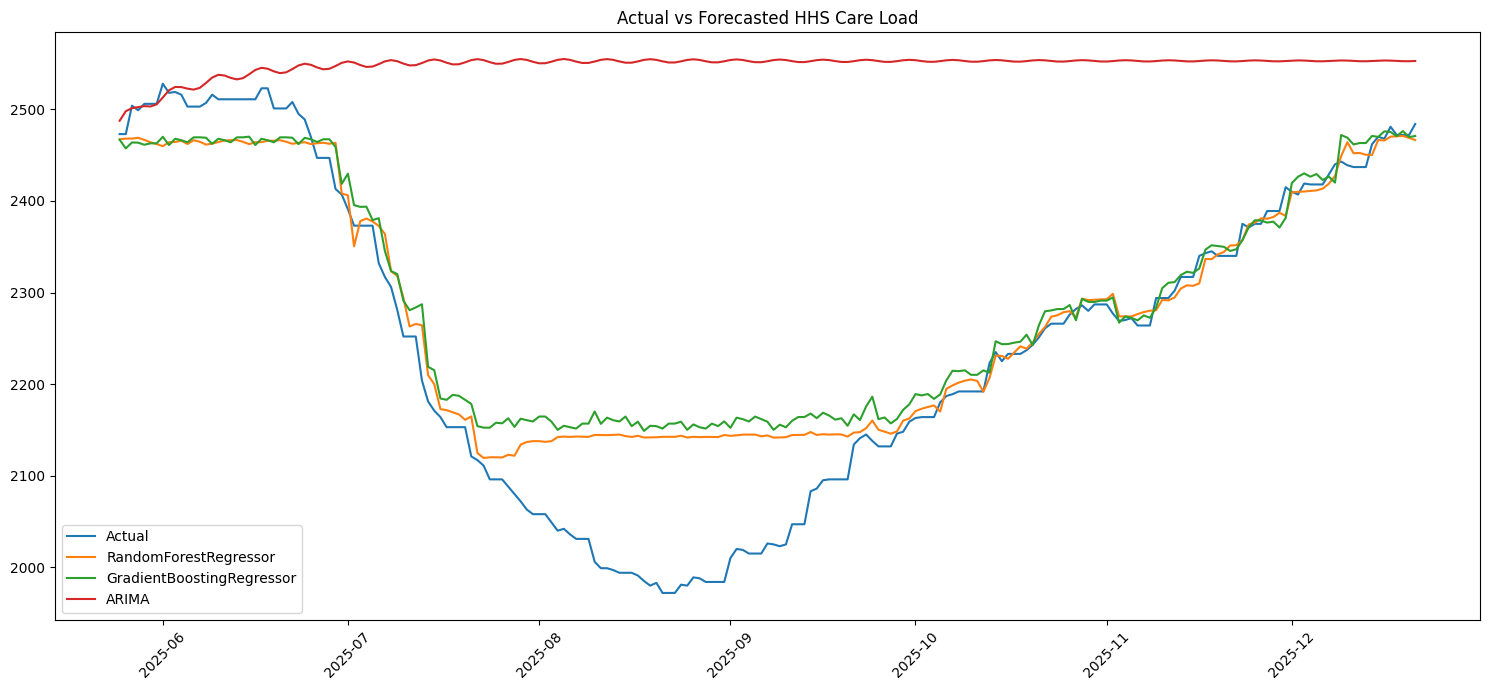

In [62]:
plt.figure(figsize=(15,7))
plt.plot(test_series.index, test_series, label="Actual")
plt.plot(test_series.index, pred, label = "RandomForestRegressor")
plt.plot(test_series.index, gb_predictions, label="GradientBoostingRegressor")
plt.plot(test_series.index, arima_predictions, label="ARIMA")
plt.title("Actual vs Forecasted HHS Care Load")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [63]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})
importance = importance.sort_values("Importance", ascending=False)
importance

,Feature,Importance
0,lag_1,0.592440
3,rolling_mean_7,0.293995
4,rolling_mean_14,0.063920
1,lag_7,0.027266
2,lag_14,0.020609
6,net_pressure,0.000458
5,rolling_std_7,0.000457
7,day_of_week,0.000427
8,month,0.000417
9,is_weekend,0.000013


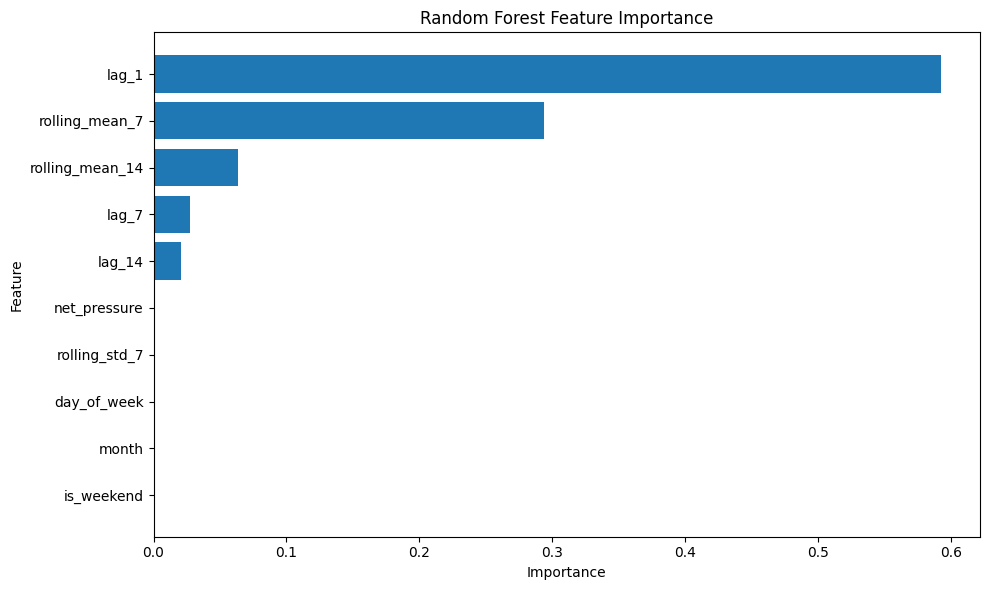

In [64]:
plt.figure(figsize=(10,6))
plt.barh(importance["Feature"], importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [65]:
def forecast_future(model,data,horizon=14):
    history = data["children_in_hhs_care"].tolist()
    future_predictions = []
    for i in range(horizon):
        lag_1 = history[-1]
        lag_7 = history[-7]
        lag_14 = history[-14]
        rolling_mean_7 = np.mean(history[-7:])
        rolling_mean_14 = np.mean(history[-14:])
        rolling_std_7 = np.std(history[-7:])
        transfer = data["children_transferred_out_of_cbp_custody"].iloc[-1]
        discharge = data["children_discharged_from_hhs_care"].iloc[-1]
        net_pressure = (transfer - discharge)
        next_date = (data.index[-1]+pd.Timedelta(days=i+1))
        day_of_week = next_date.dayofweek
        month = next_date.month
        is_weekend = int(day_of_week>=5)
        row = [[
            lag_1,
            lag_7,
            lag_14,
            rolling_mean_7,
            rolling_mean_14,
            rolling_std_7,
            net_pressure,
            day_of_week,
            month,
            is_weekend

        ]]
        prediction = model.predict(row)[0]
        future_predictions.append(prediction)
        history.append(prediction)
    return future_predictions

In [66]:
future_predictions = forecast_future(model,healthcare,horizon=14)

c:\Users\SIMON\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\SIMON\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\SIMON\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\SIMON\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\SIMON\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn

In [67]:
future_dates = pd.date_range(start=healthcare.index[-1]+pd.Timedelta(days=1),
                             periods=14,
                             freq="D"
                             )

In [68]:
future_healt = pd.DataFrame({
    "date": future_dates,
    "predicted_hhs_care": future_predictions
})
future_healt = future_healt.set_index("date")
future_healt

,predicted_hhs_care
date,
2025-12-22,2467.863333
2025-12-23,2468.070000
2025-12-24,2469.883333
2025-12-25,2470.690000
2025-12-26,2470.830000
2025-12-27,2468.920000
2025-12-28,2466.380000
2025-12-29,2468.183333
2025-12-30,2468.183333


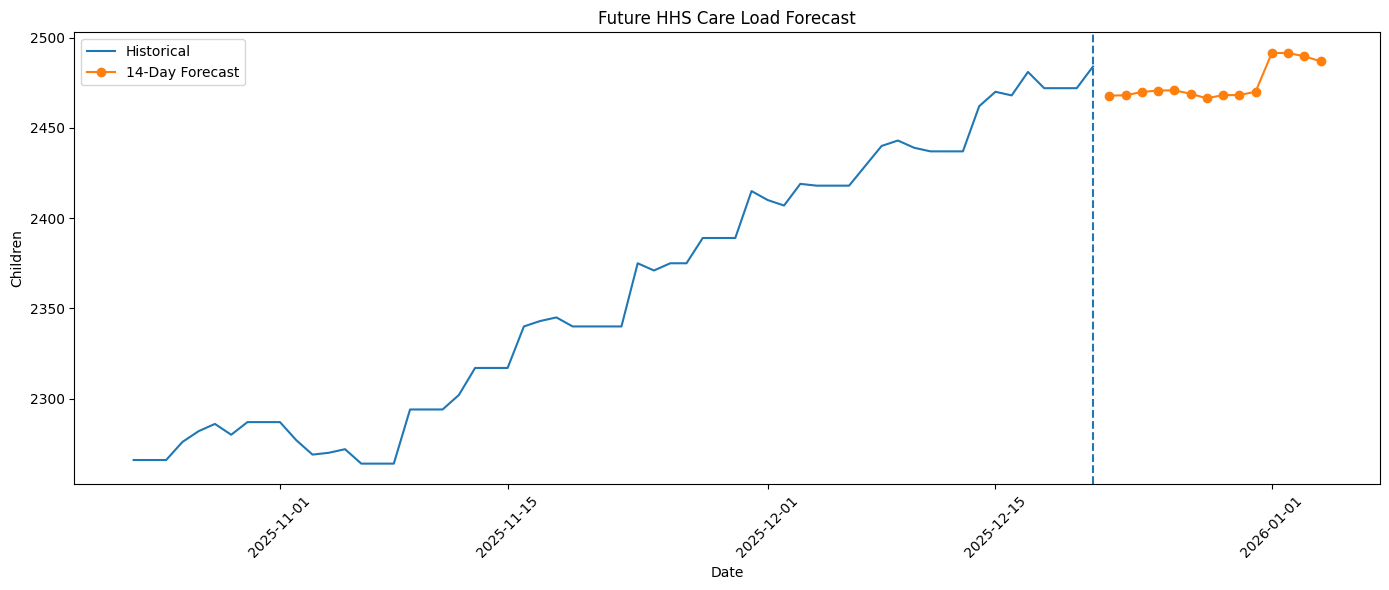

In [69]:
plt.figure(figsize=(14,6))
plt.plot(healthcare.index[-60:], healthcare["children_in_hhs_care"].iloc[-60:], label="Historical")
plt.plot(future_healt.index, future_healt["predicted_hhs_care"], marker="o", label="14-Day Forecast")
plt.axvline(healthcare.index[-1], linestyle="--")
plt.title("Future HHS Care Load Forecast")
plt.xlabel("Date")
plt.ylabel("Children")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [70]:
target_discharge = ("children_discharged_from_hhs_care")

In [71]:
healthcare["discharge_lag_1"] = (healthcare[target_discharge].shift(1))
healthcare["discharge_lag_7"] = (healthcare[target_discharge].shift(7))
healthcare["discharge_lag_14"] = (healthcare[target_discharge].shift(14))
healthcare["discharge_rolling_7"] = (healthcare[target_discharge].rolling(7).mean())
healthcare["discharge_rolling_14"] = (healthcare[target_discharge].rolling(14).mean())

In [72]:
discharge_features =[
    "discharge_lag_1",
    "discharge_lag_7",
    "discharge_lag_14",
    "discharge_rolling_7",
    "discharge_rolling_14",
    "children_transferred_out_of_cbp_custody",
    "children_in_hhs_care",
    "net_pressure",
    "day_of_week",
    "month"
]

In [73]:
discharge_df = healthcare.dropna(subset=discharge_features+[target_discharge])

In [74]:
X = discharge_df[
    discharge_features
]

y = discharge_df[
    target_discharge
]

split = int(len(discharge_df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [75]:
discharge_model = RandomForestRegressor(n_estimators=300,max_depth=12,random_state=42,n_jobs=-1)
discharge_model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

In [76]:
discharge_predictions = (discharge_model.predict(X_test))

In [77]:
print("\n Discharge MAE:", mean_absolute_error(y_test,discharge_predictions))
print("\n Discharge RMSE:", np.sqrt(mean_squared_error(y_test,discharge_predictions)))


 Discharge MAE: 1.8713787368045733

 Discharge RMSE: 2.4438737160770017


In [78]:
capacity_limit = 1500

future_healt["capacity_breach"] = (
    future_healt["predicted_hhs_care"] >= capacity_limit
)

future_healt

,predicted_hhs_care,capacity_breach
date,,
2025-12-22,2467.863333,True
2025-12-23,2468.070000,True
2025-12-24,2469.883333,True
2025-12-25,2470.690000,True
2025-12-26,2470.830000,True
2025-12-27,2468.920000,True
2025-12-28,2466.380000,True
2025-12-29,2468.183333,True
2025-12-30,2468.183333,True


In [79]:
future_df_features = []

history = healthcare[target].tolist()
transfer = healthcare["children_transferred_out_of_cbp_custody"].iloc[-1]
discharge = healthcare["children_discharged_from_hhs_care"].iloc[-1]
net_pressure = transfer - discharge

for i, next_date in enumerate(future_dates):
    row = {
        "lag_1": history[-1],
        "lag_7": history[-7],
        "lag_14": history[-14],
        "rolling_mean_7": np.mean(history[-7:]),
        "rolling_mean_14": np.mean(history[-14:]),
        "rolling_std_7": np.std(history[-7:], ddof=1),
        "net_pressure": net_pressure,
        "day_of_week": next_date.dayofweek,
        "month": next_date.month,
        "is_weekend": int(next_date.dayofweek >= 5),
    }

    future_df_features.append(row)
    history.append(future_predictions[i])

future_df_features = pd.DataFrame(future_df_features)[features]

tree_predictions = np.array([
    tree.predict(future_df_features)
    for tree in model.estimators_
])

c:\Users\SIMON\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\SIMON\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\SIMON\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\SIMON\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\SIMON\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has featur

In [80]:
lower_boun =np.percentile(tree_predictions,5,axis=0)
upper_bound = np.percentile(tree_predictions,95,axis=0)

In [81]:
capacity_limit = 1500

In [82]:
breach_dates = future_healt[
    future_healt["predicted_hhs_care"]
    >= capacity_limit
]

In [83]:
if len(breach_dates) > 0:

    first_breach = breach_dates.index[0]

    lead_time = (
        first_breach - healthcare.index[-1]
    ).days

    print(
        "Capacity breach expected in:",
        lead_time,
        "days"
    )

else:

    print(
        "No capacity breach in forecast horizon."
    )

Capacity breach expected in: 1 days
